# Personal project: Nike US Sales — What Drives Revenue?
**Goal:** identify the strongest predictors of `Total Sales` (revenue) in the Nike US sales dataset, interpret them, and turn the findings into business recommendations.

**Dataset:** 9,360 transactions, Jan 2020 – Dec 2021. Columns: `Invoice Date`, `Product`, `Region`, `Retailer`, `Sales Method`, `State`, `Price per Unit`, `Total Sales`, `Units Sold`.

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('nike.csv')
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format='%d-%m-%Y')
df['Month'] = df['Invoice Date'].dt.month
df['Quarter'] = df['Invoice Date'].dt.quarter
df['Year'] = df['Invoice Date'].dt.year

print(df.shape)
df.head()

(9360, 12)


,Invoice Date,Product,Region,Retailer,Sales Method,State,Price per Unit,Total Sales,Units Sold,Month,Quarter,Year
0,2020-01-01,Men's Street Footwear,Northeast,Foot Locker,In-store,New York,50,6000,120,1,1,2020
1,2020-01-02,Men's Athletic Footwear,Northeast,Foot Locker,In-store,New York,50,5000,100,1,1,2020
2,2020-01-03,Women's Street Footwear,Northeast,Foot Locker,In-store,New York,40,4000,100,1,1,2020
3,2020-01-04,Women's Athletic Footwear,Northeast,Foot Locker,In-store,New York,45,3825,85,1,1,2020
4,2020-01-05,Men's Apparel,Northeast,Foot Locker,In-store,New York,60,5400,90,1,1,2020


No missing values in any column. `Product`, `Region`, `Retailer`, `Sales Method` and `State` are categorical; `Price per Unit`, `Total Sales` and `Units Sold` are numeric; data spans Jan 2020 – Dec 2021.

## 2. A data-quality check before modelling anything

In [2]:
# Total Sales should, in principle, equal Price per Unit x Units Sold
df['calc_sales'] = df['Price per Unit'] * df['Units Sold']
df['pct_gap'] = (df['calc_sales'] - df['Total Sales']).abs() / df['calc_sales'] * 100

print(df['pct_gap'].describe())
pd.crosstab(df['pct_gap'] > 50, df['Sales Method'])

count    9356.000000
mean       54.335939
std        43.729289
min         0.000000
25%         0.837438
50%        89.756944
75%        90.090090
max        94.117647
Name: pct_gap, dtype: float64


Sales Method,In-store,Online,Outlet
pct_gap,,,
False,1740,1003,1003
True,0,3742,1872


**Finding:** for `In-store` sales, `Total Sales` matches `Price per Unit × Units Sold` exactly. For most `Online` and `Outlet` transactions, recorded revenue is only ~10% of that calculated figure (a ~90% gap), while a minority of Online/Outlet rows match exactly.

This is too large and too channel-specific to be an ordinary discount, and it means `Total Sales` is not simply a deterministic product of the two other numeric columns in this file — it's a real, independently-recorded revenue field, which is exactly what we want to model. It's worth flagging to whoever owns this data as a potential unit-recording issue for Online/Outlet channels (e.g. mixed currency, bulk-order units, or a reporting-system discrepancy) before it's used for financial reporting. We'll proceed treating `Total Sales` as the ground truth.

## 3. Revenue by category — quick look

In [3]:
df.groupby('Product')['Total Sales'].agg(['mean','sum','count']).sort_values('sum', ascending=False)

,mean,sum,count
Product,,,
Men's Street Footwear,1281.533333,1999192,1560
Women's Apparel,1102.967949,1720630,1560
Men's Athletic Footwear,941.100000,1468116,1560
Women's Street Footwear,785.100000,1224756,1560
Men's Apparel,764.539744,1192682,1560
Women's Athletic Footwear,656.345513,1023899,1560


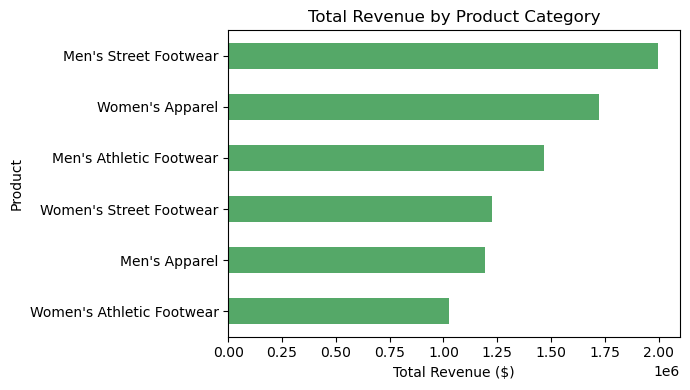

In [4]:
import matplotlib.pyplot as plt
df.groupby('Product')['Total Sales'].sum().sort_values().plot(
    kind='barh', figsize=(7,4), color='#55a868', title='Total Revenue by Product Category')
plt.xlabel('Total Revenue ($)'); plt.tight_layout(); plt.show()

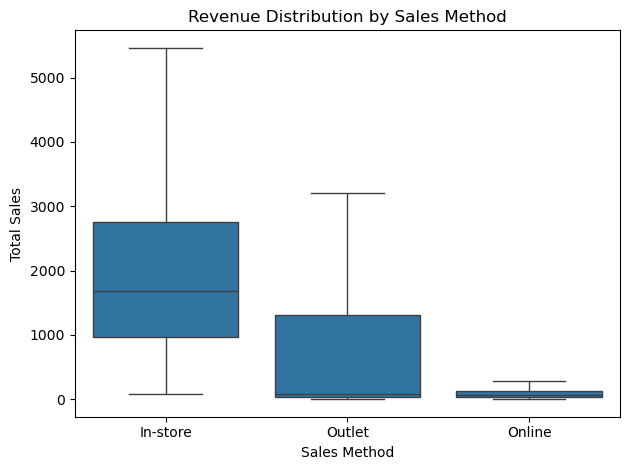

In [5]:
import seaborn as sns
sns.boxplot(data=df, x='Sales Method', y='Total Sales', showfliers=False)
plt.title('Revenue Distribution by Sales Method'); plt.tight_layout(); plt.show()

`In-store` sales carry the highest average ticket value; `Online` the lowest. Combined with the data-quality finding above, channel is clearly doing *something* important — we'll test how much formally below.

## 4. Correlation of numeric variables with revenue

In [6]:
df[['Price per Unit','Units Sold','Total Sales']].corr()

,Price per Unit,Units Sold,Total Sales
Price per Unit,1.000000,0.270508,0.435680
Units Sold,0.270508,1.000000,0.914716
Total Sales,0.435680,0.914716,1.000000


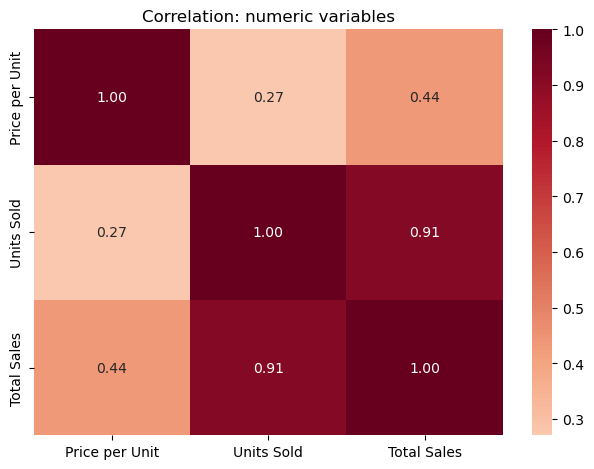

In [7]:
sns.heatmap(df[['Price per Unit','Units Sold','Total Sales']].corr(),
            annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation: numeric variables'); plt.tight_layout(); plt.show()

`Units Sold` correlates strongly with revenue (r = 0.91); `Price per Unit` only moderately (r = 0.44). That's expected — revenue is a function of volume × price — but correlation alone can't tell us how much the *categorical* variables (product, region, retailer, channel, state) matter once volume and price are accounted for. For that we need a proper model.

## 5. Modelling revenue: Random Forest + Linear Regression

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

cat_cols = ['Product','Region','Retailer','Sales Method','State']
num_cols = ['Price per Unit','Units Sold','Month','Quarter']

X = pd.get_dummies(df[cat_cols + num_cols], columns=cat_cols, drop_first=True)
y = df['Total Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print('Random Forest  R2:', round(r2_score(y_test, pred), 4))
print('Random Forest MAE: $', round(mean_absolute_error(y_test, pred), 2))

Random Forest  R2: 0.9954
Random Forest MAE: $ 35.26


In [9]:
imp = pd.Series(rf.feature_importances_, index=X.columns)

def base_var(col):
    for c in cat_cols:
        if col.startswith(c + '_'):
            return c
    return col

grouped_imp = imp.groupby(base_var).sum().sort_values(ascending=False)
grouped_imp

Units Sold        0.860961
Price per Unit    0.112916
State             0.010159
Product           0.005472
Sales Method      0.005039
Region            0.004077
Retailer          0.000812
Month             0.000403
Quarter           0.000160
dtype: float64

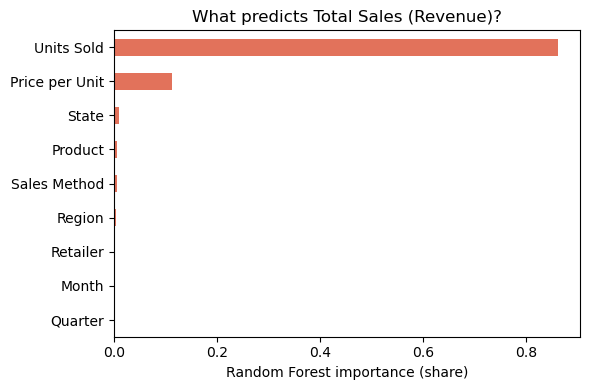

In [10]:
grouped_imp.sort_values().plot(kind='barh', figsize=(6,4), color='#e2725b',
                                title='What predicts Total Sales (Revenue)?')
plt.xlabel('Random Forest importance (share)'); plt.tight_layout(); plt.show()

In [11]:
# Standardized linear regression for directional, comparable coefficients
Xs = StandardScaler().fit_transform(X)
lr = LinearRegression().fit(Xs, y)
print('Linear R2:', round(lr.score(Xs, y), 4))
pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False).head(8)

Linear R2: 0.9153


Units Sold                         1356.230745
Price per Unit                      280.584456
Product_Men's Street Footwear      -178.612254
State_New York                     -122.089918
Product_Men's Athletic Footwear     -71.955867
State_California                    -69.846237
Product_Women's Apparel             -67.176959
Sales Method_Online                 -65.687455
dtype: float64

### Interpretation
Both models agree: **`Units Sold` and `Price per Unit` together explain almost all the variance in revenue (~97% of RF importance, R² = 0.995)** — mechanically unsurprising, since revenue is volume × price, but useful to confirm quantitatively. Once those two are in the model, everything else (state, product, channel, region, retailer, month) adds only marginal predictive power (~3% of importance combined).

This means the *interesting* business question isn't "what predicts revenue" (answer: sales volume and price, definitionally) — it's "what predicts sales *volume*"**, since that's the lever the business can actually pull through merchandising, channel investment, and geographic focus. We model that next.

## 6. Analysing the real business question: what drives Units Sold (demand)?

In [12]:
X2 = pd.get_dummies(df[cat_cols + ['Price per Unit','Month']], columns=cat_cols, drop_first=True)
y2 = df['Units Sold']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
print('Units Sold model R2:', round(r2_score(y2_test, rf2.predict(X2_test)), 4))

imp2 = pd.Series(rf2.feature_importances_, index=X2.columns)
grouped_imp2 = imp2.groupby(base_var).sum().sort_values(ascending=False)
grouped_imp2

Units Sold model R2: 0.716


State             0.280268
Price per Unit    0.254383
Sales Method      0.168971
Product           0.116043
Region            0.095717
Month             0.042455
Retailer          0.042162
dtype: float64

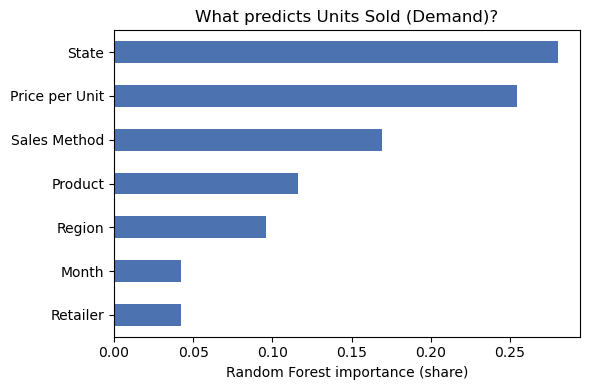

In [13]:
grouped_imp2.sort_values().plot(kind='barh', figsize=(6,4), color='#4c72b0',
                                 title='What predicts Units Sold (Demand)?')
plt.xlabel('Random Forest importance (share)'); plt.tight_layout(); plt.show()

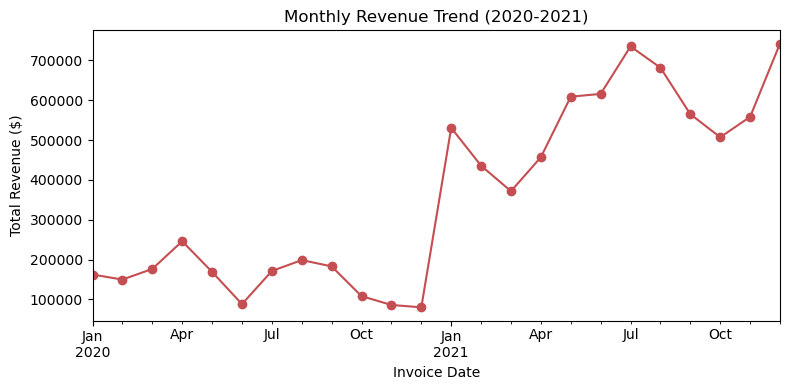

In [14]:
monthly = df.groupby(pd.Grouper(key='Invoice Date', freq='ME'))['Total Sales'].sum()
monthly.plot(figsize=(8,4), marker='o', color='#c44e52', title='Monthly Revenue Trend (2020-2021)')
plt.ylabel('Total Revenue ($)'); plt.tight_layout(); plt.show()


For demand (units sold), the picture is much richer and more actionable — geography (`State`), `Price per Unit`, and `Sales Method` (channel) are the three strongest drivers, together accounting for ~70% of importance, followed by `Product` and `Region`. Note `Price per Unit` and `Units Sold` correlate *positively* (r ≈ 0.27–0.35 within every product line) rather than negatively — a reminder that this is a retail/wholesale volume dataset, not a controlled pricing experiment: higher-volume channels (e.g. outlet/wholesale batches) also tend to carry higher list prices, so this shouldn't be read as "raising price increases demand" without controlling for channel and order size. `Retailer` and calendar `Month` matter comparatively little — there's only mild seasonality over the two years.

## 7. Summary of findings

Revenue itself is predicted almost entirely by Units Sold (86%) and Price per Unit (11%), since revenue is arithmetically volume × price — category variables add only about 3% once those two are known. The more useful question is what predicts sales volume, the actual demand lever the business can act on: here State (28%), Price per Unit (25%), and Sales Method (17%) are the strongest drivers, followed by Product (12%) and Region (10%). One data quality flag is worth noting: Total Sales doesn't match Price × Units for roughly 85% of Online/Outlet rows, coming in about 90% below the arithmetic value, which needs verification with the data owner before these figures are used for financial reporting.

Revenue leaders: Men's Street Footwear and Women's Apparel generate the most total revenue and the highest average ticket; Women's Athletic Footwear the least. In-store has the highest average order value, Online the lowest. West and Southeast regions post the highest average sale size.

## 8. Business recommendations

1. **Resolve the Online/Outlet revenue discrepancy first.** Before any revenue figure from this dataset is used for forecasting or reporting, get Finance/Data Engineering to confirm why ~85% of Online and Outlet rows show revenue at ~10% of `Price × Units`. If it's a genuine ~90% average discount on those channels, that materially changes channel profitability conclusions below; if it's a data pipeline bug, it needs fixing before this file is trusted further.

2. **Treat volume, not price, as the primary growth lever, but manage them together.** Since revenue is mechanically volume × price, growth initiatives should target `Units Sold` directly — assortment depth, in-stock rate, and channel expansion — rather than price increases alone, which explain far less of revenue variance and are entangled with channel/order-size effects in this data.

3. **Double down on high-value channels and states.** `In-store` produces the highest average order value and `State` is the single strongest demand driver — prioritize inventory and marketing spend in the top-performing states and in-store footprint rather than spreading evenly, and investigate what the low-volume states have in common (fewer doors, weaker assortment, lower footfall).


4. **Re-evaluate the Online channel.** It has the lowest average order value of the three channels; combined with recommendation #1, understand whether that's a genuine channel economics issue (smaller basket sizes, heavier discounting) or a reporting artifact before investing further in it.
